# 零基础实战机器学习
第12讲 RNN的优化
作者 黄佳

极客时间专栏链接：https://time.geekbang.org/column/intro/438

问题：根据App的历史激活（即下载后注册用户并使用App）数字，来预测其未来走势

易速鲜花公司拥有过去两年App的日激活数。

通过神经网络中的RNN模型，我们可以对这个时序数据集进行预测。

这里是对RNN模型的一下优化策略。

## 导入数据

In [2]:
import numpy as np #导入NumPy
import pandas as pd #导入Pandas 
df_app = pd.read_csv('../激活关12/App.csv', index_col='Date', parse_dates=['Date']) #导入数据
df_app #显示数据

,Activation
Date,
2019-01-01,419
2019-01-02,432
2019-01-03,436
2019-01-04,439
2019-01-05,439
...,...
2021-01-21,916
2021-01-22,925
2021-01-23,926


## 数据可视化


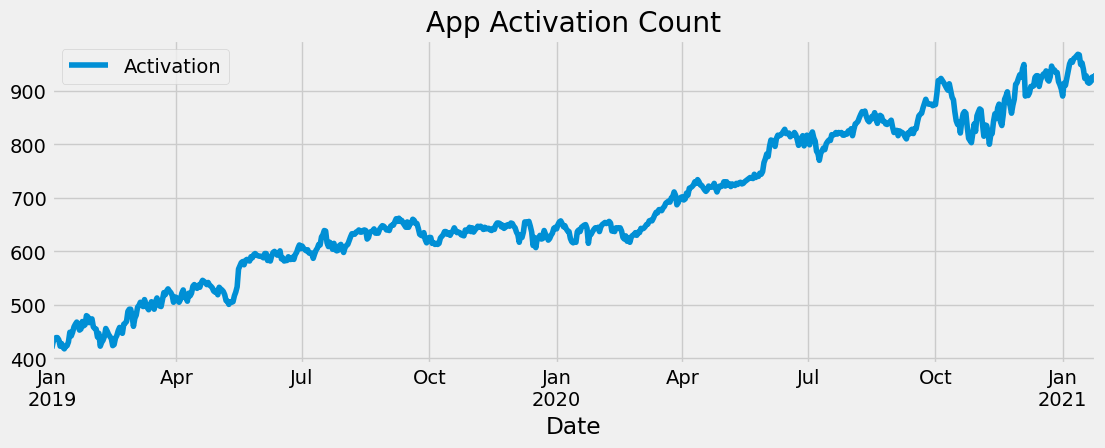

In [3]:
import matplotlib.pyplot as plt #导入matplotlib.pyplot
plt.style.use('fivethirtyeight') #设定绘图风格
df_app["Activation"].plot(figsize=(12,4),legend=True) #绘制激活数
plt.title('App Activation Count') #图题
plt.show() #绘图

## 数据清洗

In [4]:
df_app.isna().sum() #有NaN吗？

Activation    0
dtype: int64

In [5]:
(df_app.Activation < 0).values.any() #有负值吗？

False

## 拆分数据集

In [6]:
# 按照2020年10月1日为界拆分数据集
Train = df_app[:'2020-09-30'].iloc[:,0:1].values #训练集
Test = df_app['2020-10-01':].iloc[:,0:1].values #测试集

In [7]:
#Train #显示训练集对象

In [8]:
print('训练集的形状是：', Train.shape)
print('测试集的形状是：', Test.shape)

训练集的形状是： (639, 1)
测试集的形状是： (117, 1)


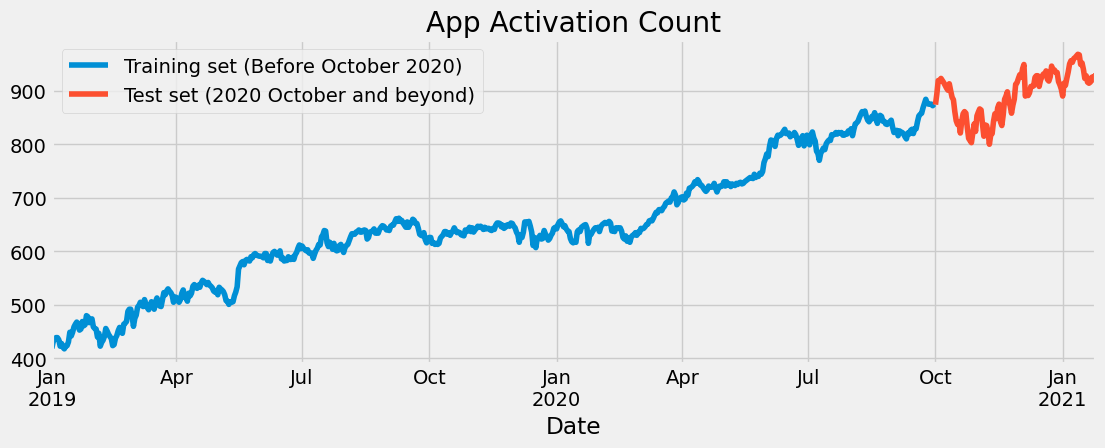

In [9]:
# 以不同颜色为训练集和测试集绘图
df_app["Activation"][:'2020-09-30'].plot(figsize=(12,4),legend=True) #训练集
df_app["Activation"]['2020-10-01':].plot(figsize=(12,4),legend=True) #测试集
plt.legend(['Training set (Before October 2020)','Test set (2020 October and beyond)']) #图例
plt.title('App Activation Count') #图题
plt.show() #绘图

## 特征工程

In [10]:
from sklearn.preprocessing import MinMaxScaler #导入归一化缩放器
Scaler = MinMaxScaler(feature_range=(0,1)) #创建缩放器
Train = Scaler.fit_transform(Train) #拟合缩放器并对训练集进行归一化

## 构建特征集和标签集

In [11]:
# 创建具有 60 个时间步长和 1 个输出的数据结构 - 训练集
X_train = [] #初始化
y_train = [] #初始化
for i in range(60,Train.size): 
    X_train.append(Train[i-60:i,0]) #构建特征
    y_train.append(Train[i,0]) #构建标签
X_train, y_train = np.array(X_train), np.array(y_train) #转换为NumPy数组
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1)) #转换成神经网络所需的张量形状

In [12]:
X_train.shape #X_train的形状

(579, 60, 1)

In [13]:
TrainTest = df_app["Activation"][:] #整体数据
inputs = TrainTest[len(TrainTest)-len(Test) - 60:].values #Test加上前60个时间步
inputs = inputs.reshape(-1,1) #转换形状
inputs  = Scaler.transform(inputs) #归一化
# 创建具有 60 个时间步长和 1 个输出的数据结构 - 测试集
X_test = [] #初始化
y_test = [] #初始化
for i in range(60,inputs.size): 
    X_test.append(inputs[i-60:i,0]) #构建特征
    y_test.append(inputs[i,0]) #构建标签
X_test = np.array(X_test) #转换为NumPy数组
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1)) #转换成神经网络所需的张量形状

In [14]:
X_test.shape #X_test的形状

(117, 60, 1)

In [16]:
#!pip install keras
#!pip install tensorflow

In [17]:
import tensorflow as tf
print(tf.__version__)

2.19.0


## 选择算法

这里我们采用RNN神经网络算法

In [18]:
from tensorflow.keras.models import Sequential #导入序贯模型
from tensorflow.keras.layers import Dense, LSTM #导入全连接层和LSTM层
# from keras.optimizers import SGD
# LSTM网络架构
RNN_LSTM = Sequential() #序贯模型
RNN_LSTM.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1))) #输入层LSTM,return_sequences返回输出序列
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间1层LSTM，return_sequences返回输出序列
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间2层LSTM，return_sequences返回输出序列
RNN_LSTM.add(LSTM(units=50)) #中间3层LSTM
RNN_LSTM.add(Dense(units=1)) #输出层Dense
# 编译网络
RNN_LSTM.compile(loss='mse', #损失函数
                 optimizer='rmsprop', #优化器
                 metrics=['mae']) #评估指标
RNN_LSTM.summary() #输出神经网络结构信息

D:\Program Files\Python\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 训练并保存训练历史信息
history = RNN_LSTM.fit(X_train, y_train, # 指定训练集
                  epochs=50,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_split=0.2) #这里直接从训练集数据中拆分验证集，更方便

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0990 - mae: 0.2656 - val_loss: 0.0332 - val_mae: 0.1767
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0048 - mae: 0.0559 - val_loss: 0.0936 - val_mae: 0.3027
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0081 - mae: 0.0749 - val_loss: 0.1099 - val_mae: 0.3285
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0090 - mae: 0.0796 - val_loss: 0.0496 - val_mae: 0.2183
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0039 - mae: 0.0482 - val_loss: 0.0033 - val_mae: 0.0459
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0098 - mae: 0.0851 - val_loss: 0.0033 - val_mae: 0.0464
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0079 - mae: 0.0754 - val_loss: 0.0021 - val_mae: 0.0374
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0098 - mae: 0.0810 - val_loss: 0.0071 - val_mae: 0.0731
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0075 - mae: 0.0725 -

In [20]:
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss'] #训练损失
    val_loss = history.history['val_loss'] #验证损失
    epochs = range(1, len(loss) + 1) #训练轮次
    plt.figure(figsize=(12,4)) # 图片大小
    plt.subplot(1, 2, 1) #子图1
    plt.plot(epochs, loss, 'bo', label='Training loss') #训练损失
    plt.plot(epochs, val_loss, 'b', label='Validation loss') #验证损失
    plt.title('Training and validation loss') #图题
    plt.xlabel('Epochs') #X轴文字
    plt.ylabel('Loss') #Y轴文字
    plt.legend() #图例
    plt.show() #绘图

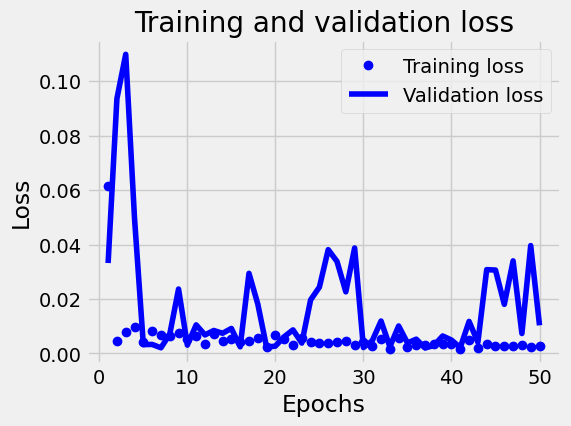

In [21]:
show_history(history) # 调用绘图函数

In [22]:
# 定义绘图函数
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real Count') #真值
    plt.plot(predicted, color='blue',label='Predicted Count') #预测值
    plt.title('Flower App Activation Prediction') #图题
    plt.xlabel('Time') #X轴时间
    plt.ylabel('Flower App Activation Count') #Y轴激活数
    plt.legend() #图例
    plt.show() #绘图

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step


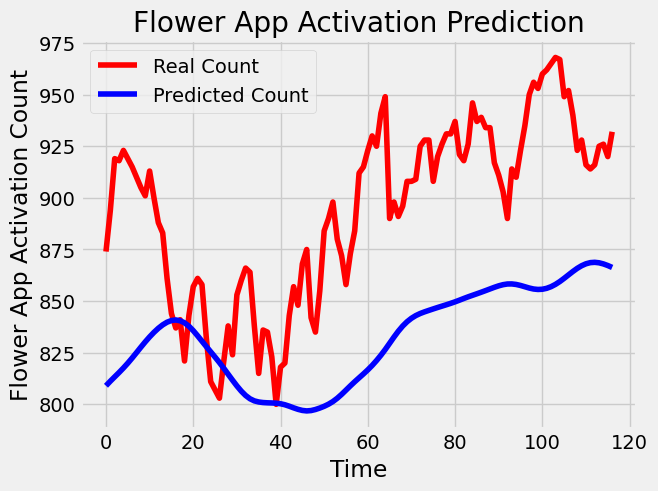

In [23]:
y_pred = RNN_LSTM.predict(X_test) #预测
Pred = Scaler.inverse_transform(y_pred) #反归一化
plot_predictions(Test,Pred) #绘图

In [20]:
# import math #导入数学函数
# 
# def return_rmse(test,predicted): #定义均方损失函数
#     rmse = math.sqrt(mean_squared_error(test, predicted)) #均方损失
#     print("MSE损失值 {}.".format(rmse))

In [24]:
from sklearn.metrics import mean_squared_error
print("调优前MSE损失值 {}.".format(mean_squared_error(y_test,y_pred)))

调优前MSE损失值 0.02235727139088886.


## 第一个调优

In [25]:
from tensorflow.keras.models import Sequential #导入序贯模型
from tensorflow.keras.layers import Dense, LSTM, Dropout #导入全连接层,LSTM层和Dropout层
# from keras.optimizers import SGD
# LSTM网络架构
RNN_LSTM = Sequential() #序贯模型
RNN_LSTM.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1))) #输入层LSTM,return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2))
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间1层LSTM，return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2))
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间2层LSTM，return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2))
RNN_LSTM.add(LSTM(units=50)) #中间3层LSTM
RNN_LSTM.add(Dropout(0.2))
RNN_LSTM.add(Dense(units=1)) #输出层Dense
# 编译网络
RNN_LSTM.compile(loss='mse', #损失函数
                 optimizer='rmsprop', #优化器
                 metrics=['mae']) #评估指标
RNN_LSTM.summary() #输出神经网络结构信息

D:\Program Files\Python\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - loss: 0.1344 - mae: 0.3083 - val_loss: 0.0405 - val_mae: 0.1962
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0072 - mae: 0.0665 - val_loss: 0.0074 - val_mae: 0.0750
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0132 - mae: 0.0938 - val_loss: 0.0037 - val_mae: 0.0494
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0150 - mae: 0.1023 - val_loss: 0.0265 - val_mae: 0.1563
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0089 - mae: 0.0736 - val_loss: 0.0183 - val_mae: 0.1276
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0087 - mae: 0.0736 - val_loss: 0.0088 - val_mae: 0.0828
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0075 - mae: 0.0719 - val_loss: 0.0078 - val_mae: 0.0769
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0094 - mae: 0.0772 - val_loss: 0.0130 - val_mae: 0.1037
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0179 - mae: 0.1084 -

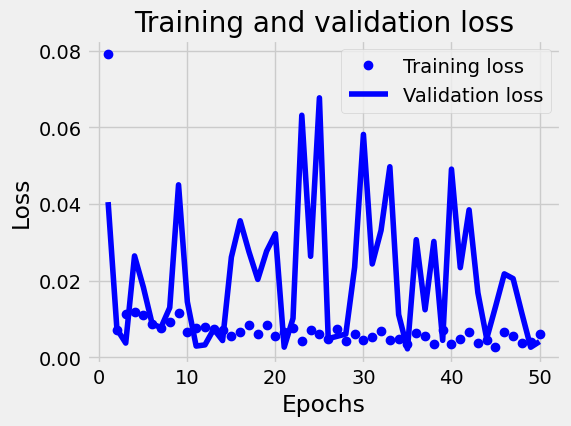

In [26]:
# 训练并保存训练历史信息
history = RNN_LSTM.fit(X_train, y_train, # 指定训练集
                  epochs=50,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_split=0.2) #这里直接从训练集数据中拆分验证集，更方便
show_history(history) # 调用绘图函数

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


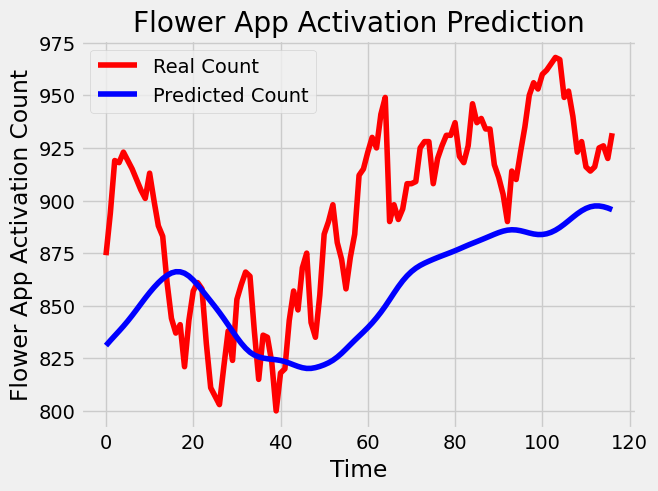

In [27]:
y_pred = RNN_LSTM.predict(X_test) #预测
Pred = Scaler.inverse_transform(y_pred) #反归一化
plot_predictions(Test,Pred) #绘图

In [28]:
print("增加Dropout层后得MSE损失值 {}.".format(mean_squared_error(y_test,y_pred)))

增加Dropout层后得MSE损失值 0.011026402977155375.


## 第二个调优

改变优化器，同时设置学习速率。

In [30]:
from tensorflow.keras.models import Sequential #导入序贯模型
from tensorflow.keras.layers import Dense, LSTM, Dropout #导入全连接层,LSTM层和Dropout层
from tensorflow.keras.optimizers import Adam
# LSTM网络架构
RNN_LSTM = Sequential() #序贯模型
RNN_LSTM.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1))) #输入层LSTM,return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2)) #Dropout层减少过拟合
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间层LSTM，return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2)) #Dropout层减少过拟合
RNN_LSTM.add(LSTM(units=50, return_sequences=True)) #中间层LSTM，return_sequences返回输出序列
RNN_LSTM.add(Dropout(0.2)) #Dropout层减少过拟合
RNN_LSTM.add(LSTM(units=50)) #中间层LSTM
RNN_LSTM.add(Dropout(0.2)) #Dropout层减少过拟合
RNN_LSTM.add(Dense(units=1)) #输出层Dense
# 编译网络
RNN_LSTM.compile(loss='mse', # 损失函数
             optimizer=Adam(learning_rate=1e-4), # 更新优化器并设定学习速率
             metrics=['mae']) # 评估指标
RNN_LSTM.summary() #输出神经网络结构信息

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                       │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.2006 - mae: 0.4262 - val_loss: 0.5578 - val_mae: 0.7454
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1379 - mae: 0.3517 - val_loss: 0.3670 - val_mae: 0.6041
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0770 - mae: 0.2566 - val_loss: 0.1811 - val_mae: 0.4231
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0286 - mae: 0.1444 - val_loss: 0.0401 - val_mae: 0.1949
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0071 - mae: 0.0663 - val_loss: 0.0030 - val_mae: 0.0448
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0120 - mae: 0.0889 - val_loss: 0.0093 - val_mae: 0.0852
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0069 - mae: 0.0667 - val_loss: 0.0300 - val_mae: 0.1669
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0074 - mae: 0.0633 - val_loss: 0.0365 - val_mae: 0.1853
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0061 - mae: 0.0595 -

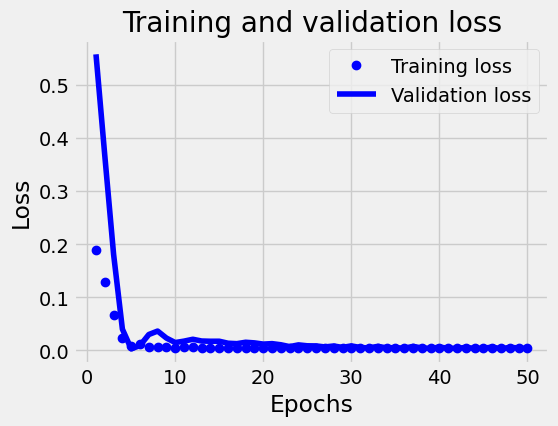

In [31]:
# 训练并保存训练历史信息
history = RNN_LSTM.fit(X_train, y_train, # 指定训练集
                  epochs=50,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_split=0.2) #这里直接从训练集数据中拆分验证集，更方便
show_history(history) # 调用绘图函数

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 394ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F3B30CA680> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step


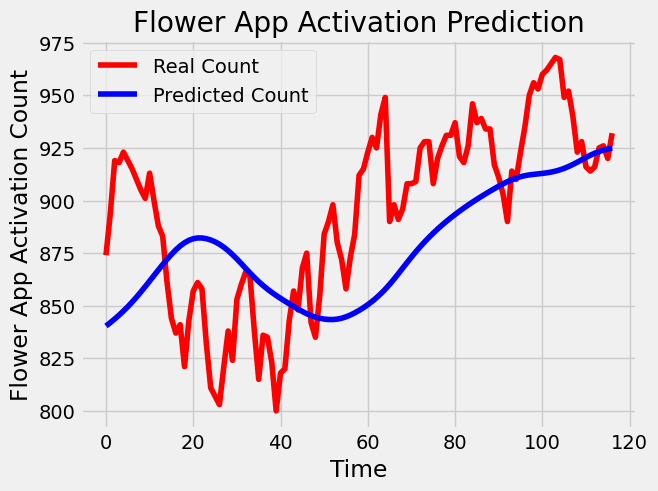

In [32]:
y_pred = RNN_LSTM.predict(X_test) #预测
Pred = Scaler.inverse_transform(y_pred) #反归一化
plot_predictions(Test,Pred) #绘图

In [33]:
print("设置优化器后的MSE损失值 {}.".format(mean_squared_error(y_test, y_pred)))

设置优化器后的MSE损失值 0.0076588139289194.
